# AG-UNet: Attention Gate UNet for Lung Tumor Segmentation
## Hybrid Loss: Dice + Focal + Boundary

**Architecture:** UNet with Attention Gates + Squeeze-and-Excitation Blocks  
**Loss:** Dice Loss (0.5) + Focal Loss (0.3) + Boundary Loss (0.2)  
**Dataset:** Lung Cancer Segmentation (Kaggle – rasoulisaeid)

---
### Expected Dataset Structure
```
dataset/
├── train/
│   ├── patient_001/
│   │   ├── data/    <- *.npy CT slices
│   │   └── masks/   <- *.npy binary masks
│   └── ... (57 folders)
└── val/
    ├── patient_058/
    │   ├── data/
    │   └── masks/
    └── ...
```

## 1. Install Dependencies

In [1]:
!pip install torch torchvision numpy scipy matplotlib scikit-image tqdm -q

## 2. Imports & Configuration

In [2]:
import os
import csv
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from scipy.ndimage import distance_transform_edt
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
# ── Configuration (optimised for RTX 4060 / Windows) ─────────────────────────
CFG = {
    # Paths
    'data_dir'   : 'dataset',        # <-- change this to your dataset path
    'output_dir' : 'outputs',

    # Training
    'epochs'     : 50,
    'batch_size' : 16,               # RTX 4060 8GB handles 16 comfortably
    'lr'         : 1e-4,
    'weight_decay': 1e-5,
    'num_workers': 0,                # Windows must use 0
    'pin_memory' : False,            # no benefit with num_workers=0
    'patience'   : 10,
    'amp'        : torch.cuda.is_available(),  # FP16 — major speedup on 4060

    # Model
    'in_channels': 1,
    'features'   : [64, 128, 256, 512],
    'dropout'    : 0.1,

    # Hybrid Loss weights
    'w_dice'     : 0.5,
    'w_focal'    : 0.3,
    'w_boundary' : 0.2,

    # Focal loss params
    'focal_alpha': 0.8,
    'focal_gamma': 2.0,

    # LR Scheduler
    'T0'         : 10,
    'T_mult'     : 2,

    # HD95 uses scipy on CPU per sample — only compute every N val epochs
    'hd95_every' : 5,
}

os.makedirs(CFG['output_dir'], exist_ok=True)

# cuDNN benchmark: finds fastest conv algo for your GPU on first batch, reuses it
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print('Configuration loaded ✓')
print(f'  batch_size      : {CFG["batch_size"]}')
print(f'  amp (FP16)      : {CFG["amp"]}')
print(f'  cudnn.benchmark : {torch.backends.cudnn.benchmark}')

Configuration loaded ✓
  batch_size      : 16
  amp (FP16)      : True
  cudnn.benchmark : True


## 3. Dataset & Dataloader

In [4]:
class LungTumorDataset(Dataset):
    """
    Dataset loader for lung tumor segmentation.
    Pairs data/*.npy with masks/*.npy by sorted filename order.
    """

    def __init__(self, root_dir, split='train', augment=True):
        self.split   = split
        self.augment = augment and (split == 'train')
        self.samples = []

        split_dir       = os.path.join(root_dir, split)
        patient_folders = sorted(os.listdir(split_dir))

        for patient in patient_folders:
            data_dir = os.path.join(split_dir, patient, 'data')
            mask_dir = os.path.join(split_dir, patient, 'masks')
            if not os.path.isdir(data_dir) or not os.path.isdir(mask_dir):
                continue
            data_files = sorted(os.listdir(data_dir))
            mask_files = sorted(os.listdir(mask_dir))
            for df, mf in zip(data_files, mask_files):
                self.samples.append((
                    os.path.join(data_dir, df),
                    os.path.join(mask_dir, mf)
                ))

        print(f'[{split}] Loaded {len(self.samples)} slices from {len(patient_folders)} patients.')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        data_path, mask_path = self.samples[idx]
        image = np.load(data_path).astype(np.float32)
        mask  = np.load(mask_path).astype(np.float32)

        # Handle 3D volumes: take middle slice
        if image.ndim == 3 and image.shape[0] > 3:
            mid = image.shape[0] // 2
            image = image[mid]; mask = mask[mid]

        image = self._normalize(image)

        # Ensure 2D (H, W)
        if image.ndim == 3: image = image[0]
        if mask.ndim  == 3: mask  = mask[0]

        # Add channel dim -> (1, H, W)
        image = image[np.newaxis]
        mask  = mask[np.newaxis]
        mask  = (mask > 0.5).astype(np.float32)

        if self.augment:
            image, mask = self._augment(image, mask)

        return torch.tensor(image, dtype=torch.float32), \
               torch.tensor(mask,  dtype=torch.float32)

    def _normalize(self, x):
        xmin, xmax = x.min(), x.max()
        return (x - xmin) / (xmax - xmin + 1e-6)

    def _augment(self, image, mask):
        if random.random() > 0.5:
            image = np.flip(image, axis=2).copy()
            mask  = np.flip(mask,  axis=2).copy()
        if random.random() > 0.5:
            image = np.flip(image, axis=1).copy()
            mask  = np.flip(mask,  axis=1).copy()
        if random.random() > 0.5:
            k     = random.randint(1, 3)
            image = np.rot90(image, k, axes=(1, 2)).copy()
            mask  = np.rot90(mask,  k, axes=(1, 2)).copy()
        if random.random() > 0.5:
            image = np.clip(image * random.uniform(0.8, 1.2), 0, 1)
        return image, mask


# Build dataloaders
train_ds = LungTumorDataset(CFG['data_dir'], split='train', augment=True)
val_ds   = LungTumorDataset(CFG['data_dir'], split='val',   augment=False)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                          shuffle=True,  num_workers=CFG['num_workers'], pin_memory=CFG['pin_memory'])
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=CFG['num_workers'], pin_memory=CFG['pin_memory'])

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

[train] Loaded 14432 slices from 57 patients.
[val] Loaded 1335 slices from 6 patients.
Train batches: 902 | Val batches: 84


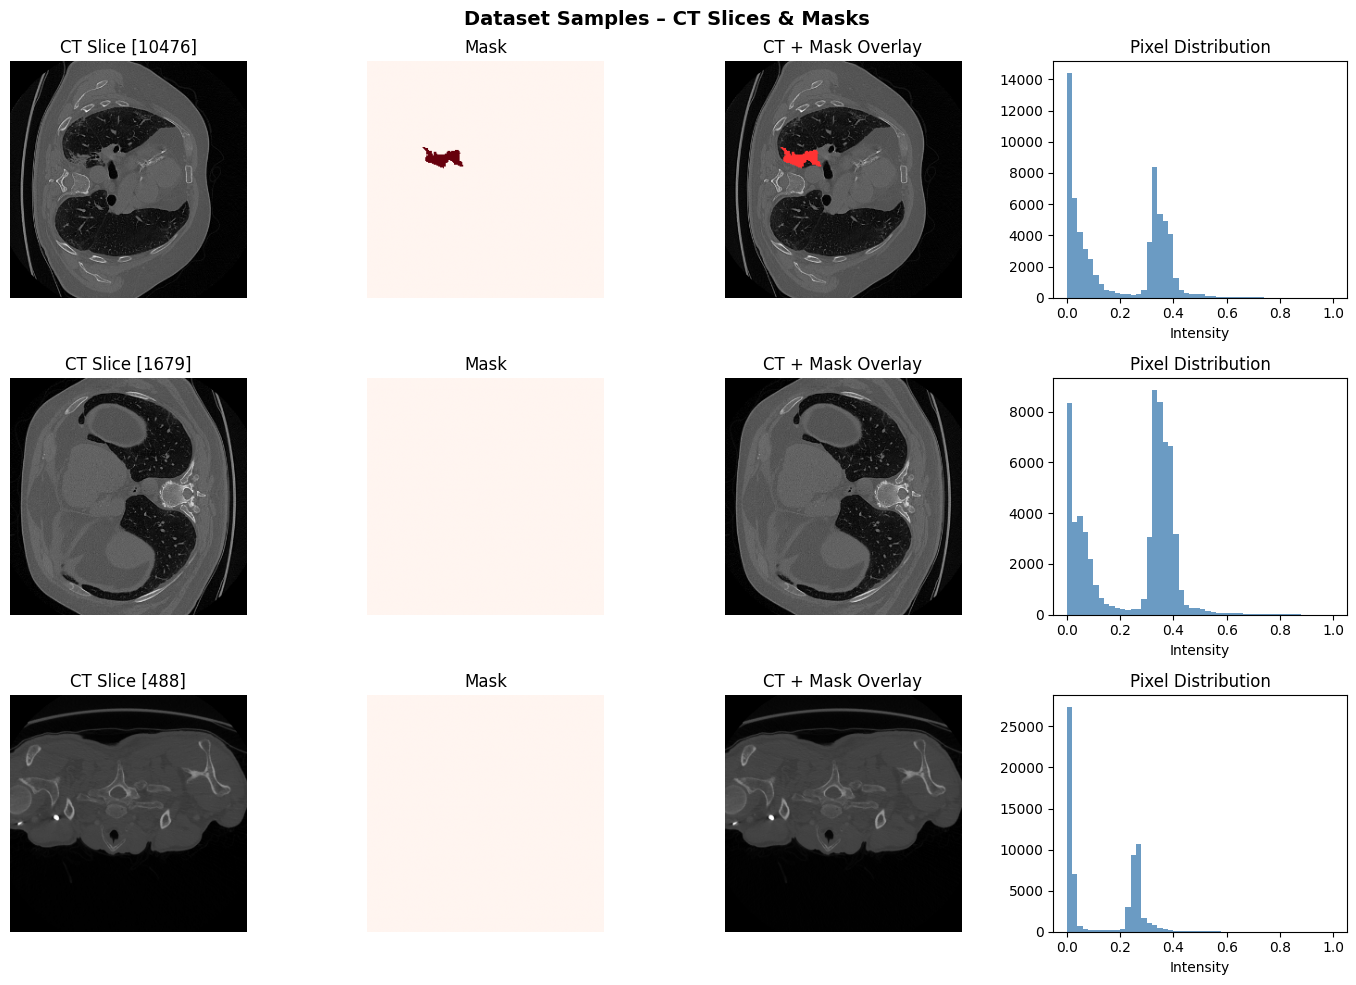

Dataset samples saved ✓


In [5]:
# ── Visualize a few samples ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Dataset Samples – CT Slices & Masks', fontsize=14, fontweight='bold')

for row in range(3):
    idx   = random.randint(0, len(train_ds) - 1)
    img, mask = train_ds[idx]
    img_np  = img[0].numpy()
    mask_np = mask[0].numpy()

    axes[row, 0].imshow(img_np,  cmap='gray');   axes[row, 0].set_title(f'CT Slice [{idx}]')
    axes[row, 1].imshow(mask_np, cmap='Reds', vmin=0, vmax=1); axes[row, 1].set_title('Mask')

    # Overlay
    overlay = np.stack([img_np]*3, axis=-1)
    overlay[mask_np > 0.5, 0] = 1.0
    overlay[mask_np > 0.5, 1] = 0.2
    overlay[mask_np > 0.5, 2] = 0.2
    axes[row, 2].imshow(overlay); axes[row, 2].set_title('CT + Mask Overlay')

    # Histogram
    axes[row, 3].hist(img_np.flatten(), bins=50, color='steelblue', alpha=0.8)
    axes[row, 3].set_title('Pixel Distribution')
    axes[row, 3].set_xlabel('Intensity')

for ax in axes.flatten():
    if ax.images: ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], 'dataset_samples.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Dataset samples saved ✓')

## 4. Model Architecture – AG-UNet

In [6]:
# ── Building Blocks ───────────────────────────────────────────────────────────

class DoubleConv(nn.Module):
    """(Conv -> BN -> ReLU) x 2 with optional dropout."""
    def __init__(self, in_ch, out_ch, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class SEBlock(nn.Module):
    """Squeeze-and-Excitation Block for channel-wise recalibration."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        scale = self.pool(x).view(b, c)
        scale = self.fc(scale).view(b, c, 1, 1)
        return x * scale


class AttentionGate(nn.Module):
    """
    Attention Gate (Oktay et al., 2018).
    Learns spatial attention weights to focus on tumor regions in skip connections.
    g  : gating signal from decoder  (B, F_g, H, W)
    x  : skip connection from encoder (B, F_l, H, W)
    """
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g,  F_int, 1, bias=False), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l,  F_int, 1, bias=False), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1,    1, bias=False), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi   # attended skip features


# ── AG-UNet ───────────────────────────────────────────────────────────────────

class AGUNet(nn.Module):
    """
    Attention Gate UNet with SE Blocks.
    Encoder: DoubleConv + SE → MaxPool
    Decoder: ConvTranspose → AttentionGate → Concat → DoubleConv
    """
    def __init__(self, in_channels=1, out_channels=1,
                 features=[64, 128, 256, 512], dropout=0.1):
        super().__init__()
        self.downs     = nn.ModuleList()
        self.ups       = nn.ModuleList()
        self.att_gates = nn.ModuleList()
        self.se_blocks = nn.ModuleList()
        self.pool      = nn.MaxPool2d(2, 2)

        # Encoder
        ch = in_channels
        for feat in features:
            self.downs.append(DoubleConv(ch, feat, dropout))
            self.se_blocks.append(SEBlock(feat))
            ch = feat

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2, dropout)

        # Decoder
        for feat in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feat * 2, feat, 2, stride=2))
            self.att_gates.append(AttentionGate(F_g=feat, F_l=feat, F_int=feat // 2))
            self.ups.append(DoubleConv(feat * 2, feat, dropout))

        self.final_conv = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []

        for down, se in zip(self.downs, self.se_blocks):
            x = down(x); x = se(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i in range(0, len(self.ups), 2):
            x    = self.ups[i](x)
            skip = skips[i // 2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
            attended = self.att_gates[i // 2](g=x, x=skip)
            x = torch.cat([attended, x], dim=1)
            x = self.ups[i + 1](x)

        return self.final_conv(x)


# Build and inspect model
model = AGUNet(
    in_channels=CFG['in_channels'],
    features=CFG['features'],
    dropout=CFG['dropout']
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

# Sanity check forward pass
dummy = torch.randn(2, 1, 256, 256).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'Input shape : {dummy.shape}')
print(f'Output shape: {out.shape}')   # should be (2, 1, 256, 256)
print('Model architecture ready ✓')

Total parameters    : 31,430,569
Trainable parameters: 31,430,569
Input shape : torch.Size([2, 1, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])
Model architecture ready ✓


## 5. Hybrid Loss Function

In [7]:
class DiceLoss(nn.Module):
    """Soft Dice Loss."""
    def __init__(self, smooth=1e-6):
        super().__init__(); self.smooth = smooth
    def forward(self, logits, targets):
        probs  = torch.sigmoid(logits).view(-1)
        tgts   = targets.view(-1)
        inter  = (probs * tgts).sum()
        return 1 - (2 * inter + self.smooth) / (probs.sum() + tgts.sum() + self.smooth)


class FocalLoss(nn.Module):
    """Binary Focal Loss."""
    def __init__(self, alpha=0.8, gamma=2.0):
        super().__init__(); self.alpha = alpha; self.gamma = gamma
    def forward(self, logits, targets):
        bce   = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t   = torch.sigmoid(logits) * targets + (1 - torch.sigmoid(logits)) * (1 - targets)
        return (self.alpha * (1 - p_t) ** self.gamma * bce).mean()


class BoundaryLoss(nn.Module):
    """
    Fast GPU Boundary Loss using morphological erosion (MaxPool trick).
    Extracts the boundary of the GT mask entirely on GPU — no scipy, no CPU round-trip.
    Uses BCEWithLogits which is AMP-safe (no sigmoid before BCE).
    """
    def __init__(self, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.erode = nn.MaxPool2d(kernel_size, stride=1, padding=pad)

    def forward(self, logits, targets):
        eroded   = -self.erode(-targets)           # min-pool == erosion
        boundary = (targets - eroded).clamp(0, 1)  # thin ring around edges
        # BCEWithLogits is AMP-safe (takes raw logits, no sigmoid needed)
        return F.binary_cross_entropy_with_logits(logits, boundary)


class HybridLoss(nn.Module):
    """Hybrid Loss = w_dice*Dice + w_focal*Focal + w_boundary*Boundary"""
    def __init__(self, w_dice=0.5, w_focal=0.3, w_boundary=0.2, alpha=0.8, gamma=2.0):
        super().__init__()
        self.w_dice = w_dice; self.w_focal = w_focal; self.w_boundary = w_boundary
        self.dice     = DiceLoss()
        self.focal    = FocalLoss(alpha, gamma)
        self.boundary = BoundaryLoss()

    def forward(self, logits, targets):
        d = self.dice(logits, targets)
        f = self.focal(logits, targets)
        b = self.boundary(logits, targets)
        total = self.w_dice * d + self.w_focal * f + self.w_boundary * b
        return total, {'dice_loss': d.item(), 'focal_loss': f.item(),
                       'boundary_loss': b.item(), 'total_loss': total.item()}


criterion = HybridLoss(
    w_dice=CFG['w_dice'], w_focal=CFG['w_focal'], w_boundary=CFG['w_boundary'],
    alpha=CFG['focal_alpha'], gamma=CFG['focal_gamma']
)

# Quick test
dummy_logits  = torch.randn(2, 1, 256, 256)
dummy_targets = (torch.randn(2, 1, 256, 256) > 0).float()
loss, breakdown = criterion(dummy_logits, dummy_targets)
print('Hybrid Loss test (AMP-safe, 100% GPU):')
for k, v in breakdown.items():
    print(f'  {k}: {v:.4f}')
print('Loss function ready ✓')

Hybrid Loss test (AMP-safe, 100% GPU):
  dice_loss: 0.4980
  focal_loss: 0.2754
  boundary_loss: 0.8030
  total_loss: 0.4922
Loss function ready ✓


## 6. Metrics

In [8]:
def dice_coeff(pred, target, smooth=1e-6):
    p, t = pred.flatten().astype(float), target.flatten().astype(float)
    return (2 * (p * t).sum() + smooth) / (p.sum() + t.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    p, t = pred.flatten().astype(float), target.flatten().astype(float)
    inter = (p * t).sum()
    return (inter + smooth) / (p.sum() + t.sum() - inter + smooth)

def prec_rec_spec(pred, target):
    p, t = pred.flatten().astype(float), target.flatten().astype(float)
    TP = (p * t).sum(); FP = (p * (1-t)).sum()
    FN = ((1-p) * t).sum(); TN = ((1-p) * (1-t)).sum()
    return TP/(TP+FP+1e-6), TP/(TP+FN+1e-6), TN/(TN+FP+1e-6)

def hd95(pred, target):
    """95th-percentile Hausdorff Distance (scipy, CPU). Expensive — use sparingly."""
    pp = np.argwhere(pred > 0).astype(float)
    tp = np.argwhere(target > 0).astype(float)
    if len(pp) == 0 and len(tp) == 0: return 0.0
    if len(pp) == 0 or len(tp) == 0:  return np.inf
    d1, _ = cKDTree(pp).query(tp)
    d2, _ = cKDTree(tp).query(pp)
    return float(np.percentile(np.concatenate([d1, d2]), 95))


class MetricTracker:
    """Accumulates segmentation metrics. HD95 is opt-in (expensive)."""
    def __init__(self, compute_hd95=False):
        self.compute_hd95 = compute_hd95
        self.reset()

    def reset(self):
        self._dice = []; self._iou  = []; self._prec = []
        self._rec  = []; self._spec = []; self._hd95 = []

    def update(self, logits, targets, threshold=0.5):
        preds   = (torch.sigmoid(logits).detach().cpu().numpy() > threshold).astype(np.uint8)
        targets = targets.detach().cpu().numpy().astype(np.uint8)
        for b in range(preds.shape[0]):
            p, t = preds[b, 0], targets[b, 0]
            self._dice.append(dice_coeff(p, t))
            self._iou.append(iou_score(p, t))
            pr, re, sp = prec_rec_spec(p, t)
            self._prec.append(pr); self._rec.append(re); self._spec.append(sp)
            if self.compute_hd95:
                self._hd95.append(hd95(p, t))

    def compute(self):
        hd = [h for h in self._hd95 if np.isfinite(h)]
        return {
            'dice'       : float(np.mean(self._dice)),
            'iou'        : float(np.mean(self._iou)),
            'precision'  : float(np.mean(self._prec)),
            'recall'     : float(np.mean(self._rec)),
            'specificity': float(np.mean(self._spec)),
            'hd95'       : float(np.mean(hd)) if hd else -1.0
        }

print('Metrics ready ✓')

Metrics ready ✓


## 7. Optimizer, Scheduler & Setup

In [9]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG['lr'],
    weight_decay=CFG['weight_decay']
)

scheduler = CosineAnnealingWarmRestarts(
    optimizer, T_0=CFG['T0'], T_mult=CFG['T_mult'], eta_min=1e-7
)

scaler = GradScaler(enabled=CFG['amp'])

# CSV logger
LOG_PATH = os.path.join(CFG['output_dir'], 'training_log.csv')
log_fh   = open(LOG_PATH, 'w', newline='')
fieldnames = ['epoch', 'split', 'loss', 'dice_loss', 'focal_loss',
              'boundary_loss', 'dice', 'iou', 'precision', 'recall',
              'specificity', 'hd95', 'lr']
log_writer = csv.DictWriter(log_fh, fieldnames=fieldnames)
log_writer.writeheader()

# History dict for live plotting
history = {
    'train_loss': [], 'val_loss': [],
    'train_dice': [], 'val_dice': [],
    'train_iou' : [], 'val_iou' : [],
    'val_hd95'  : [], 'val_prec': [],
    'val_rec'   : [], 'val_spec': [], 'lr': []
}

print('Optimizer, scheduler, logger ready ✓')

Optimizer, scheduler, logger ready ✓


## 8. Training Loop

In [10]:
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0.0
    loss_parts = {'dice_loss': 0, 'focal_loss': 0, 'boundary_loss': 0}
    tracker = MetricTracker()

    for images, masks in loader:
        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.to(DEVICE,  non_blocking=True)
        optimizer.zero_grad()

        with autocast(enabled=CFG['amp']):
            logits = model(images)
            loss, breakdown = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        for k in loss_parts: loss_parts[k] += breakdown[k]
        tracker.update(logits.detach(), masks)

    n = len(loader)
    m = tracker.compute()
    m['loss'] = total_loss / n
    for k in loss_parts: m[k] = loss_parts[k] / n
    return m


@torch.no_grad()
def val_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    loss_parts = {'dice_loss': 0, 'focal_loss': 0, 'boundary_loss': 0}
    tracker = MetricTracker()

    for images, masks in loader:
        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.to(DEVICE,  non_blocking=True)

        with autocast(enabled=CFG['amp']):
            logits = model(images)
            loss, breakdown = criterion(logits, masks)

        total_loss += loss.item()
        for k in loss_parts: loss_parts[k] += breakdown[k]
        tracker.update(logits, masks)

    n = len(loader)
    m = tracker.compute()
    m['loss'] = total_loss / n
    for k in loss_parts: m[k] = loss_parts[k] / n
    return m


print('Training functions ready ✓')

Training functions ready ✓


In [11]:
best_val_dice    = 0.0
patience_counter = 0
BEST_CKPT        = os.path.join(CFG['output_dir'], 'best_model.pth')

for epoch in range(1, CFG['epochs'] + 1):

    # ── TRAIN ─────────────────────────────────────────────────────────────────
    model.train()
    total_loss = 0.0
    loss_parts = {'dice_loss': 0, 'focal_loss': 0, 'boundary_loss': 0}
    tracker    = MetricTracker(compute_hd95=False)  # HD95 off during train

    for images, masks in tqdm(train_loader, desc=f'Epoch {epoch}/{CFG["epochs"]} - Train'):
        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.to(DEVICE,  non_blocking=True)
        optimizer.zero_grad()

        with autocast(enabled=CFG['amp']):
            logits = model(images)
            loss, breakdown = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        for k in loss_parts: loss_parts[k] += breakdown[k]
        tracker.update(logits.detach(), masks)

    n = len(train_loader)
    train_m = tracker.compute()
    train_m['loss'] = total_loss / n
    for k in loss_parts: train_m[k] = loss_parts[k] / n

    # ── VALIDATE ──────────────────────────────────────────────────────────────
    # Only compute expensive HD95 every hd95_every epochs
    do_hd95 = (epoch % CFG['hd95_every'] == 0) or (epoch == CFG['epochs'])
    model.eval()
    total_loss = 0.0
    loss_parts = {'dice_loss': 0, 'focal_loss': 0, 'boundary_loss': 0}
    tracker    = MetricTracker(compute_hd95=do_hd95)

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f'Epoch {epoch}/{CFG["epochs"]} - Val'):
            images = images.to(DEVICE, non_blocking=True)
            masks  = masks.to(DEVICE,  non_blocking=True)

            with autocast(enabled=CFG['amp']):
                logits = model(images)
                loss, breakdown = criterion(logits, masks)

            total_loss += loss.item()
            for k in loss_parts: loss_parts[k] += breakdown[k]
            tracker.update(logits, masks)

    n = len(val_loader)
    val_m = tracker.compute()
    val_m['loss'] = total_loss / n
    for k in loss_parts: val_m[k] = loss_parts[k] / n

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Update history
    history['train_loss'].append(train_m['loss'])
    history['val_loss'].append(val_m['loss'])
    history['train_dice'].append(train_m['dice'])
    history['val_dice'].append(val_m['dice'])
    history['train_iou'].append(train_m['iou'])
    history['val_iou'].append(val_m['iou'])
    history['val_hd95'].append(val_m['hd95'])
    history['val_prec'].append(val_m['precision'])
    history['val_rec'].append(val_m['recall'])
    history['val_spec'].append(val_m['specificity'])
    history['lr'].append(current_lr)

    # CSV log
    for split, m in [('train', train_m), ('val', val_m)]:
        row = {'epoch': epoch, 'split': split, 'lr': current_lr}
        row.update(m)
        log_writer.writerow(row)
    log_fh.flush()

    hd95_str = f'{val_m["hd95"]:.2f}' if do_hd95 else '---'
    print(f'Epoch {epoch}/{CFG["epochs"]} '
          f'| Train Loss: {train_m["loss"]:.4f} '
          f'| Val Loss: {val_m["loss"]:.4f} '
          f'| Dice: {val_m["dice"]:.4f} '
          f'| IoU: {val_m["iou"]:.4f} '
          f'| HD95: {hd95_str}')

    # Checkpoint
    if val_m['dice'] > best_val_dice:
        best_val_dice = val_m['dice']
        patience_counter = 0
        torch.save({
            'epoch'          : epoch,
            'model_state'    : model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_dice'       : best_val_dice,
            'val_metrics'    : val_m,
        }, BEST_CKPT)
        print(f'  ✓ Best model saved (val_dice={best_val_dice:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= CFG['patience']:
            print(f'Early stopping at epoch {epoch}.')
            break

    torch.cuda.empty_cache()

log_fh.close()
print(f'\nTraining complete. Best val Dice: {best_val_dice:.4f}')
print(f'Best model: {BEST_CKPT}')

Epoch 1/50 - Val: 100%|██████████| 84/84 [01:01<00:00,  1.36it/s]


Epoch 1/50 | Train Loss: 0.5373 | Val Loss: 0.5159 | Dice: 0.8981 | IoU: 0.8981 | HD95: ---
  ✓ Best model saved (val_dice=0.8981)


Epoch 2/50 - Val: 100%|██████████| 84/84 [00:12<00:00,  6.86it/s]


Epoch 2/50 | Train Loss: 0.5091 | Val Loss: 0.5056 | Dice: 0.4135 | IoU: 0.4095 | HD95: ---


Epoch 3/50 - Val: 100%|██████████| 84/84 [00:12<00:00,  6.86it/s]


...

Epoch 34/50 | Train Loss: 0.2497 | Val Loss: 0.4738 | Dice: 0.9418 | IoU: 0.9359 | HD95: ---


Epoch 35/50 - Val: 100%|██████████| 84/84 [00:12<00:00,  6.74it/s]


Epoch 35/50 | Train Loss: 0.2355 | Val Loss: 0.4724 | Dice: 0.9265 | IoU: 0.9203 | HD95: 0.43


Epoch 36/50 - Val: 100%|██████████| 84/84 [00:12<00:00,  6.91it/s]

Epoch 36/50 | Train Loss: 0.2447 | Val Loss: 0.4695 | Dice: 0.9379 | IoU: 0.9318 | HD95: ---
Early stopping at epoch 36.

Training complete. Best val Dice: 0.9456
Best model: outputs\best_model.pth


## 9. Training Curves

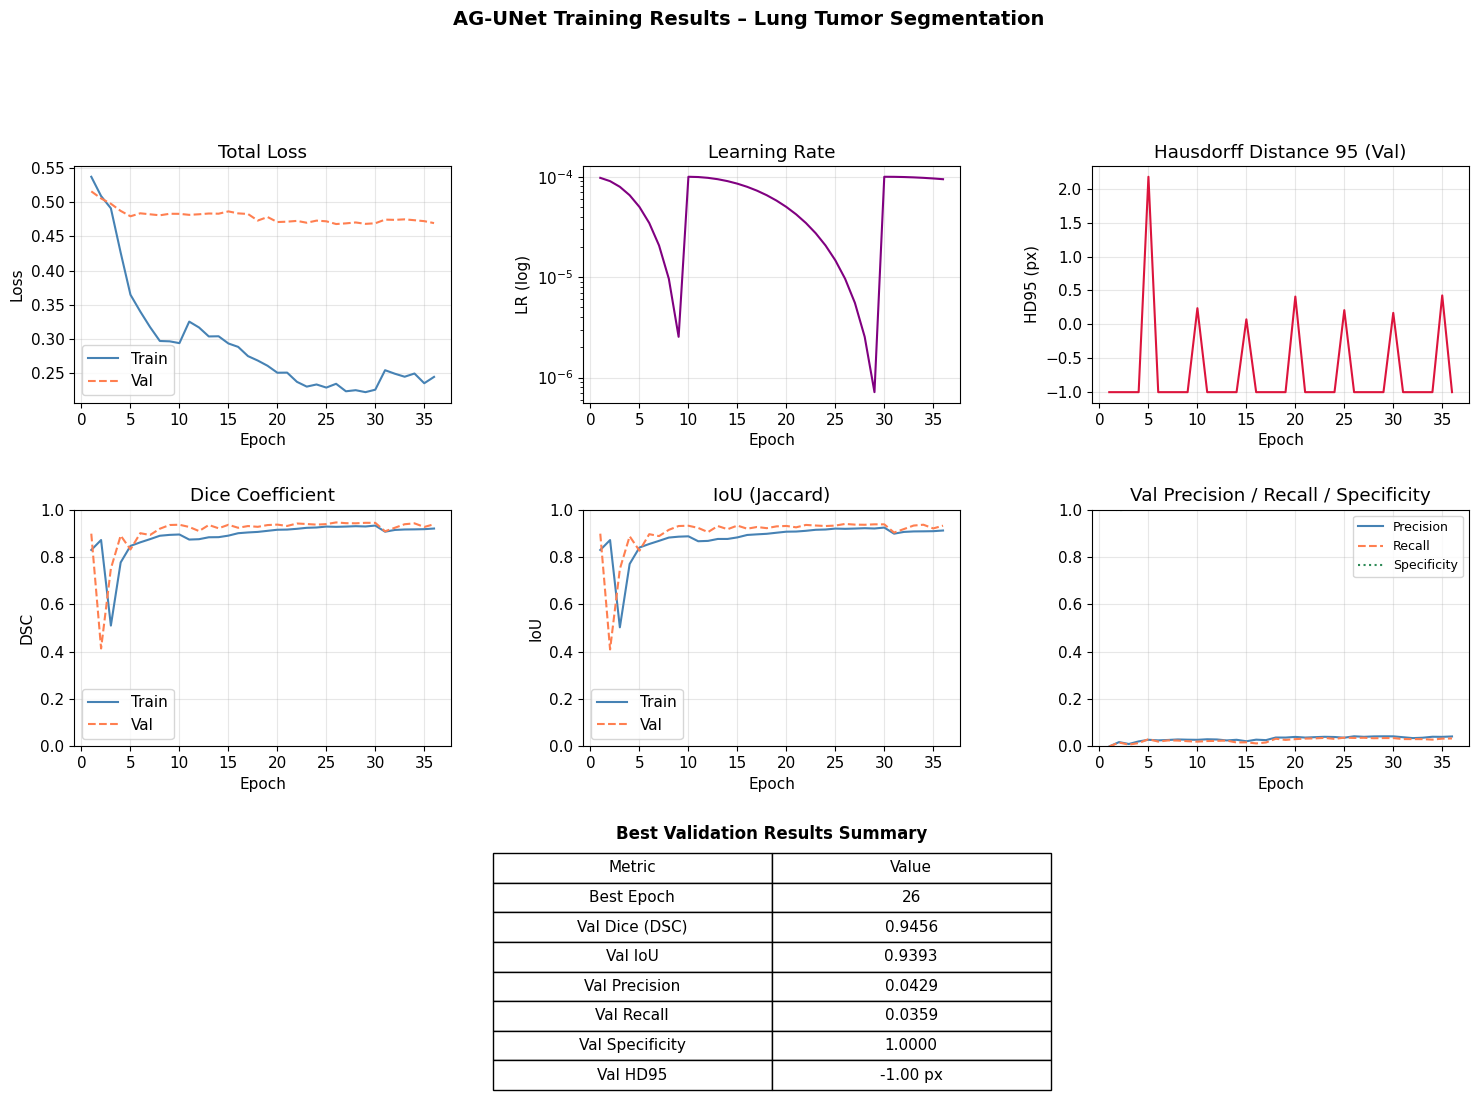

Training curves saved ✓


In [12]:
epochs_ran = list(range(1, len(history['train_loss']) + 1))

plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

def plot(ax, title, ylabel, train_key, val_key, ylim=None):
    ax.plot(epochs_ran, history[train_key], label='Train', color='steelblue')
    ax.plot(epochs_ran, history[val_key],   label='Val',   color='coral', linestyle='--')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    if ylim: ax.set_ylim(ylim)
    ax.legend()

plot(fig.add_subplot(gs[0,0]), 'Total Loss',     'Loss',  'train_loss', 'val_loss')
plot(fig.add_subplot(gs[1,0]), 'Dice Coefficient','DSC',  'train_dice', 'val_dice', [0,1])
plot(fig.add_subplot(gs[1,1]), 'IoU (Jaccard)',  'IoU',   'train_iou',  'val_iou',  [0,1])

ax = fig.add_subplot(gs[0,1])
ax.semilogy(epochs_ran, history['lr'], color='purple')
ax.set_title('Learning Rate'); ax.set_xlabel('Epoch'); ax.set_ylabel('LR (log)')

ax = fig.add_subplot(gs[0,2])
ax.plot(epochs_ran, history['val_hd95'], color='crimson')
ax.set_title('Hausdorff Distance 95 (Val)'); ax.set_xlabel('Epoch'); ax.set_ylabel('HD95 (px)')

ax = fig.add_subplot(gs[1,2])
ax.plot(epochs_ran, history['val_prec'], label='Precision', color='steelblue')
ax.plot(epochs_ran, history['val_rec'],  label='Recall',    color='coral',   linestyle='--')
ax.plot(epochs_ran, history['val_spec'], label='Specificity',color='seagreen', linestyle=':')
ax.set_title('Val Precision / Recall / Specificity'); ax.set_xlabel('Epoch')
ax.set_ylim(0, 1); ax.legend(fontsize=9)

# Summary table in last cell
ax = fig.add_subplot(gs[2, :])
ax.axis('off')
best_idx = int(np.argmax(history['val_dice']))
table_data = [
    ['Best Epoch', best_idx + 1],
    ['Val Dice (DSC)', f"{history['val_dice'][best_idx]:.4f}"],
    ['Val IoU',        f"{history['val_iou'][best_idx]:.4f}"],
    ['Val Precision',  f"{history['val_prec'][best_idx]:.4f}"],
    ['Val Recall',     f"{history['val_rec'][best_idx]:.4f}"],
    ['Val Specificity',f"{history['val_spec'][best_idx]:.4f}"],
    ['Val HD95',       f"{history['val_hd95'][best_idx]:.2f} px"],
]
tbl = ax.table(cellText=table_data, colLabels=['Metric', 'Value'],
               cellLoc='center', loc='center', bbox=[0.3, 0.0, 0.4, 1.0])
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
ax.set_title('Best Validation Results Summary', fontsize=12, fontweight='bold', pad=10)

fig.suptitle('AG-UNet Training Results – Lung Tumor Segmentation',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig(os.path.join(CFG['output_dir'], 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved ✓')

## 10. Inference & Visualization

Loaded best model from epoch 26 (val_dice=0.9456)


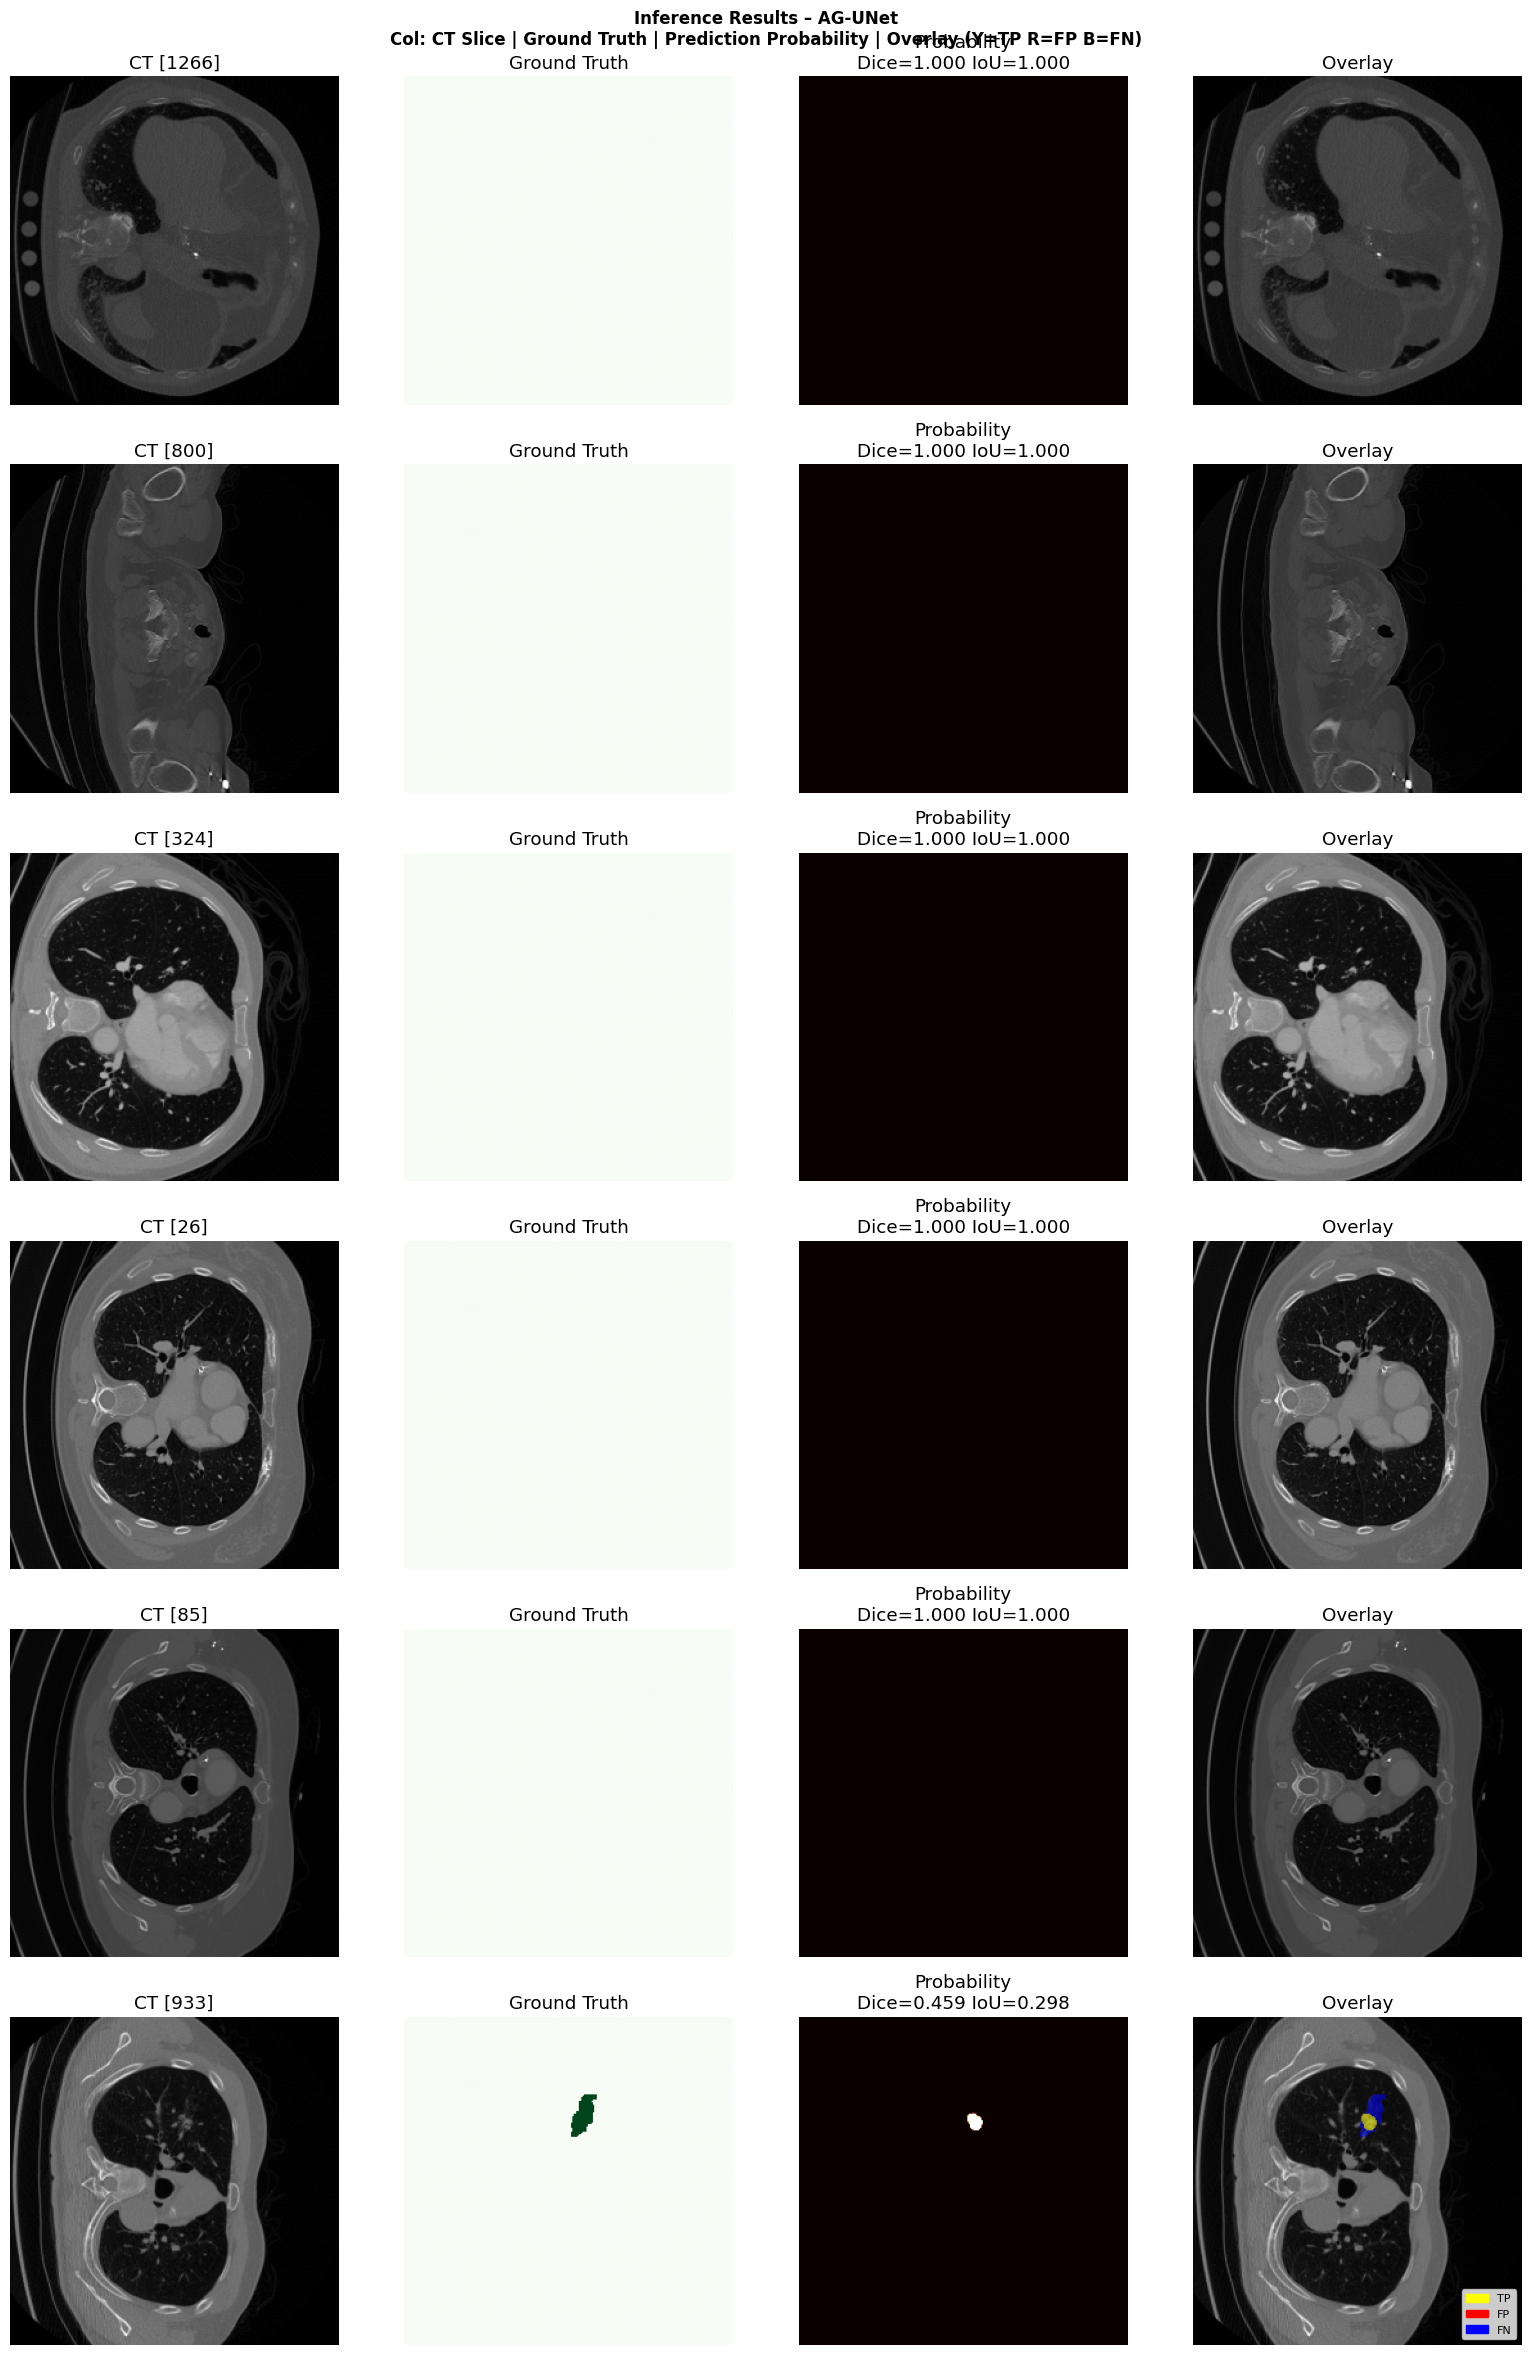

Inference visualization saved ✓


In [13]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Loaded best model from epoch {ckpt['epoch']} (val_dice={ckpt['val_dice']:.4f})")


def make_overlay(img, pred, gt, alpha=0.45):
    rgb = np.stack([img, img, img], axis=-1).copy()
    tp  = (pred > 0) & (gt > 0)
    fp  = (pred > 0) & (gt == 0)
    fn  = (pred == 0) & (gt > 0)
    # TP = yellow, FP = red, FN = blue
    for ch, tp_v, fp_v, fn_v in zip([0,1,2],[1,1,0],[1,0,0],[0,0,1]):
        rgb[tp, ch] = alpha*rgb[tp, ch] + (1-alpha)*tp_v
        rgb[fp, ch] = alpha*rgb[fp, ch] + (1-alpha)*fp_v
        rgb[fn, ch] = alpha*rgb[fn, ch] + (1-alpha)*fn_v
    return np.clip(rgb, 0, 1)


# ── Run inference on N validation samples ────────────────────────────────────
N_VIZ = 6   # change as needed
indices = random.sample(range(len(val_ds)), min(N_VIZ, len(val_ds)))

fig, axes = plt.subplots(N_VIZ, 4, figsize=(16, 4 * N_VIZ))
if N_VIZ == 1: axes = axes[np.newaxis]

fig.suptitle('Inference Results – AG-UNet\n'
             'Col: CT Slice | Ground Truth | Prediction Probability | Overlay (Y=TP R=FP B=FN)',
             fontsize=12, fontweight='bold')

global_tracker = MetricTracker()

with torch.no_grad():
    for row, idx in enumerate(indices):
        img_t, mask_t = val_ds[idx]
        inp   = img_t.unsqueeze(0).to(DEVICE)

        with autocast(enabled=CFG['amp']):
            logit = model(inp)

        prob_np = torch.sigmoid(logit)[0, 0].cpu().numpy()
        pred_np = (prob_np > 0.5).astype(np.uint8)
        mask_np = mask_t[0].numpy().astype(np.uint8)
        img_np  = img_t[0].numpy()

        dsc = dice_coeff(pred_np, mask_np)
        iou = iou_score(pred_np, mask_np)
        overlay = make_overlay(img_np, pred_np, mask_np)

        global_tracker.update(logit.cpu(), mask_t.unsqueeze(0))

        axes[row, 0].imshow(img_np,  cmap='gray')
        axes[row, 0].set_title(f'CT [{idx}]')
        axes[row, 1].imshow(mask_np, cmap='Greens', vmin=0, vmax=1)
        axes[row, 1].set_title('Ground Truth')
        axes[row, 2].imshow(prob_np, cmap='hot',   vmin=0, vmax=1)
        axes[row, 2].set_title(f'Probability\nDice={dsc:.3f} IoU={iou:.3f}')
        axes[row, 3].imshow(overlay)
        axes[row, 3].set_title('Overlay')

        # Legend on last row
        if row == N_VIZ - 1:
            patches = [mpatches.Patch(color='yellow', label='TP'),
                       mpatches.Patch(color='red',    label='FP'),
                       mpatches.Patch(color='blue',   label='FN')]
            axes[row, 3].legend(handles=patches, loc='lower right', fontsize=8)

        for ax in axes[row]: ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], 'inference_results.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Inference visualization saved ✓')

## 11. Attention Gate Visualization

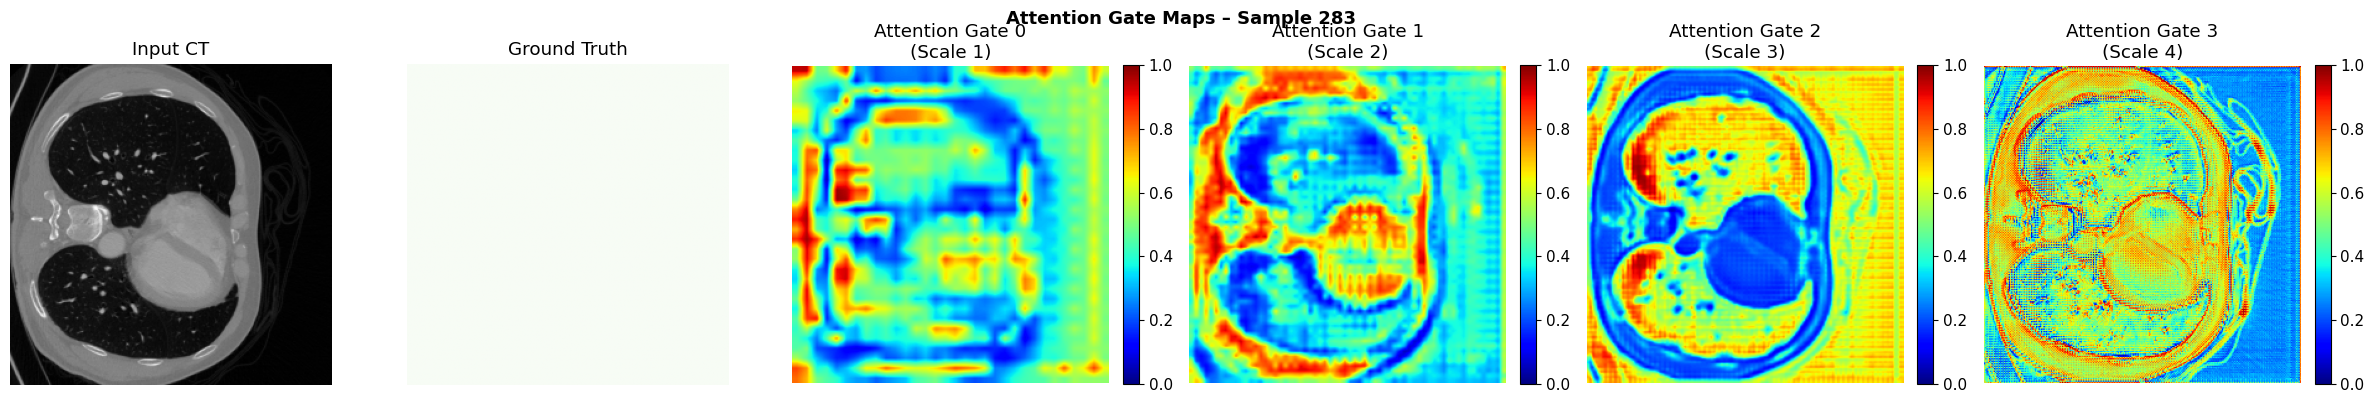

Attention gate maps saved ✓


In [14]:
# ── Hook into attention gates and visualize their spatial maps ────────────────
activations = {}

def make_hook(name):
    def hook(module, inp, out):
        activations[name] = out.detach().cpu()
    return hook

handles = []
for i, ag in enumerate(model.att_gates):
    handles.append(ag.psi.register_forward_hook(make_hook(f'att_{i}')))

# Run a single sample through
sample_idx      = random.randint(0, len(val_ds) - 1)
img_t, mask_t   = val_ds[sample_idx]
inp             = img_t.unsqueeze(0).to(DEVICE)

model.eval()
with torch.no_grad():
    with autocast(enabled=CFG['amp']):
        logit = model(inp)

for h in handles: h.remove()

# Plot
n = len(activations)
fig, axes = plt.subplots(1, n + 2, figsize=(4 * (n + 2), 4))
fig.suptitle(f'Attention Gate Maps – Sample {sample_idx}', fontsize=13, fontweight='bold')

axes[0].imshow(img_t[0].numpy(), cmap='gray')
axes[0].set_title('Input CT'); axes[0].axis('off')

axes[1].imshow(mask_t[0].numpy(), cmap='Greens', vmin=0, vmax=1)
axes[1].set_title('Ground Truth'); axes[1].axis('off')

for i, (name, att_map) in enumerate(activations.items()):
    am = att_map[0, 0].numpy()
    # Upsample to input size for visualization
    am_up = F.interpolate(
        torch.tensor(am).unsqueeze(0).unsqueeze(0),
        size=img_t.shape[1:], mode='bilinear', align_corners=False
    )[0, 0].numpy()
    im = axes[i + 2].imshow(am_up, cmap='jet', vmin=0, vmax=1)
    axes[i + 2].set_title(f'Attention Gate {i}\n(Scale {i+1})')
    axes[i + 2].axis('off')
    plt.colorbar(im, ax=axes[i + 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], 'attention_maps.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Attention gate maps saved ✓')

## 12. Final Evaluation Summary


  FINAL VALIDATION RESULTS – AG-UNet
  Dice Coefficient (DSC)        : 0.9456
  IoU (Jaccard Index)           : 0.9393
  Precision                     : 0.0429
  Recall (Sensitivity)          : 0.0359
  Specificity                   : 1.0000
  Hausdorff Distance 95 (px)    : -1.0000


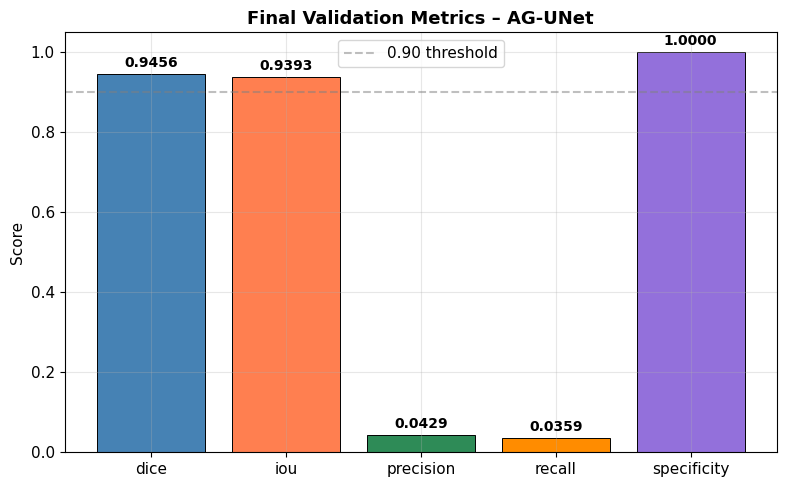

Final metrics chart saved ✓

HD95: -1.00 px
All outputs saved in: outputs/


In [15]:
# ── Full validation set evaluation ────────────────────────────────────────────
model.eval()
full_tracker = MetricTracker()

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)
        with autocast(enabled=CFG['amp']):
            logits = model(images)
        full_tracker.update(logits.cpu(), masks.cpu())

final_metrics = full_tracker.compute()

print('\n' + '='*50)
print('  FINAL VALIDATION RESULTS – AG-UNet')
print('='*50)
labels = {
    'dice'       : 'Dice Coefficient (DSC)',
    'iou'        : 'IoU (Jaccard Index)',
    'precision'  : 'Precision',
    'recall'     : 'Recall (Sensitivity)',
    'specificity': 'Specificity',
    'hd95'       : 'Hausdorff Distance 95 (px)'
}
for k, label in labels.items():
    print(f'  {label:<30}: {final_metrics[k]:.4f}')
print('='*50)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
keys    = ['dice', 'iou', 'precision', 'recall', 'specificity']
vals    = [final_metrics[k] for k in keys]
colors  = ['steelblue', 'coral', 'seagreen', 'darkorange', 'mediumpurple']
bars    = ax.bar(keys, vals, color=colors, edgecolor='black', linewidth=0.7)
ax.set_ylim(0, 1.05)
ax.set_title('Final Validation Metrics – AG-UNet', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='0.90 threshold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], 'final_metrics.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Final metrics chart saved ✓')
print(f'\nHD95: {final_metrics["hd95"]:.2f} px')
print(f'All outputs saved in: {CFG["output_dir"]}/')

In [3]:
import os, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast
from scipy.spatial import cKDTree
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ── SET THESE TWO ─────────────────────────────────────────────────────────────
CHECKPOINT_PATH = 'outputs/best_model.pth'
DATA_DIR        = 'dataset'
# ─────────────────────────────────────────────────────────────────────────────

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
THRESHOLD = 0.5

# ── Dataset ───────────────────────────────────────────────────────────────────
class LungTumorDataset(Dataset):
    def __init__(self, root_dir, split='val'):
        self.samples = []
        split_dir = os.path.join(root_dir, split)
        for patient in sorted(os.listdir(split_dir)):
            data_dir = os.path.join(split_dir, patient, 'data')
            mask_dir = os.path.join(split_dir, patient, 'masks')
            if not os.path.isdir(data_dir) or not os.path.isdir(mask_dir): continue
            for df, mf in zip(sorted(os.listdir(data_dir)), sorted(os.listdir(mask_dir))):
                self.samples.append((os.path.join(data_dir, df), os.path.join(mask_dir, mf)))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        image = np.load(self.samples[idx][0]).astype(np.float32)
        mask  = np.load(self.samples[idx][1]).astype(np.float32)
        if image.ndim == 3 and image.shape[0] > 3:
            mid = image.shape[0] // 2
            image = image[mid]; mask = mask[mid]
        xmin, xmax = image.min(), image.max()
        image = (image - xmin) / (xmax - xmin + 1e-6)
        if image.ndim == 3: image = image[0]
        if mask.ndim  == 3: mask  = mask[0]
        image = image[np.newaxis]; mask = mask[np.newaxis]
        mask  = (mask > 0.5).astype(np.float32)
        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

# ── Model ─────────────────────────────────────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True), nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.block(x)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, channels//reduction, bias=False), nn.ReLU(inplace=True),
            nn.Linear(channels//reduction, channels, bias=False), nn.Sigmoid())
    def forward(self, x):
        b, c, _, _ = x.shape
        return x * self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g  = nn.Sequential(nn.Conv2d(F_g,  F_int, 1, bias=False), nn.BatchNorm2d(F_int))
        self.W_x  = nn.Sequential(nn.Conv2d(F_l,  F_int, 1, bias=False), nn.BatchNorm2d(F_int))
        self.psi  = nn.Sequential(nn.Conv2d(F_int, 1, 1, bias=False), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        g1 = self.W_g(g); x1 = self.W_x(x)
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        return x * self.psi(self.relu(g1 + x1))

class AGUNet(nn.Module):
    def __init__(self, in_channels=1, features=[64,128,256,512], dropout=0.1):
        super().__init__()
        self.downs = nn.ModuleList(); self.ups = nn.ModuleList()
        self.att_gates = nn.ModuleList(); self.se_blocks = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)
        ch = in_channels
        for feat in features:
            self.downs.append(DoubleConv(ch, feat, dropout))
            self.se_blocks.append(SEBlock(feat)); ch = feat
        self.bottleneck = DoubleConv(features[-1], features[-1]*2, dropout)
        for feat in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feat*2, feat, 2, stride=2))
            self.att_gates.append(AttentionGate(feat, feat, feat//2))
            self.ups.append(DoubleConv(feat*2, feat, dropout))
        self.final_conv = nn.Conv2d(features[0], 1, 1)
    def forward(self, x):
        skips = []
        for down, se in zip(self.downs, self.se_blocks):
            x = down(x); x = se(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x); skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x); skip = skips[i//2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
            x = torch.cat([self.att_gates[i//2](g=x, x=skip), x], dim=1)
            x = self.ups[i+1](x)
        return self.final_conv(x)

# ── Metrics ───────────────────────────────────────────────────────────────────
def dice_coeff(p, t, smooth=1e-6):
    p, t = p.flatten().astype(float), t.flatten().astype(float)
    return (2*(p*t).sum() + smooth) / (p.sum() + t.sum() + smooth)

def iou_score(p, t, smooth=1e-6):
    p, t = p.flatten().astype(float), t.flatten().astype(float)
    inter = (p*t).sum()
    return (inter + smooth) / (p.sum() + t.sum() - inter + smooth)

def prec_rec_spec(p, t):
    p, t = p.flatten().astype(float), t.flatten().astype(float)
    if t.sum() == 0 and p.sum() == 0: return 1.0, 1.0, 1.0   # both empty — perfect
    if t.sum() == 0:                   return 0.0, 1.0, 1.0   # false alarm on empty slice
    TP = (p*t).sum();  FP = (p*(1-t)).sum()
    FN = ((1-p)*t).sum(); TN = ((1-p)*(1-t)).sum()
    return TP/(TP+FP+1e-6), TP/(TP+FN+1e-6), TN/(TN+FP+1e-6)

def hd95(p, t):
    pp = np.argwhere(p > 0).astype(float)
    tp = np.argwhere(t > 0).astype(float)
    if len(pp) == 0 and len(tp) == 0: return 0.0
    if len(pp) == 0 or  len(tp) == 0: return np.inf
    d1, _ = cKDTree(pp).query(tp)
    d2, _ = cKDTree(tp).query(pp)
    return float(np.percentile(np.concatenate([d1, d2]), 95))

# ── Load model ────────────────────────────────────────────────────────────────
model = AGUNet().to(DEVICE)
ckpt  = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Loaded checkpoint — Epoch {ckpt["epoch"]} | Training Dice {ckpt["val_dice"]:.4f}')

# ── Run evaluation ────────────────────────────────────────────────────────────
dataset = LungTumorDataset(DATA_DIR, split='val')
loader  = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=0)

all_dice, all_iou, all_prec, all_rec, all_spec, all_hd95 = [], [], [], [], [], []

with torch.no_grad():
    for images, masks in tqdm(loader, desc='Evaluating'):
        images = images.to(DEVICE)
        with autocast(enabled=torch.cuda.is_available()):
            logits = model(images)
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs > THRESHOLD).astype(np.uint8)
        masks  = masks.numpy().astype(np.uint8)

        for b in range(preds.shape[0]):
            p, t = preds[b, 0], masks[b, 0]
            all_dice.append(dice_coeff(p, t))
            all_iou.append(iou_score(p, t))
            pr, re, sp = prec_rec_spec(p, t)
            all_prec.append(pr); all_rec.append(re); all_spec.append(sp)
            all_hd95.append(hd95(p, t))

hd_finite = [h for h in all_hd95 if np.isfinite(h)]

# ── Print results ─────────────────────────────────────────────────────────────
print('\n' + '='*52)
print('   FINAL VALIDATION RESULTS  —  AG-UNet')
print(f'   Checkpoint : Epoch {ckpt["epoch"]}')
print(f'   Total slices evaluated : {len(all_dice)}')
print(f'   Tumour-positive slices : {sum(1 for h in all_hd95 if h != np.inf and h >= 0)}')
print('='*52)
print(f'  Dice (DSC)        : {np.mean(all_dice):.4f}')
print(f'  IoU (Jaccard)     : {np.mean(all_iou):.4f}')
print(f'  Precision         : {np.mean(all_prec):.4f}')
print(f'  Recall            : {np.mean(all_rec):.4f}')
print(f'  Specificity       : {np.mean(all_spec):.4f}')
print(f'  HD95 (px)         : {np.mean(hd_finite):.4f}' if hd_finite else '  HD95 (px)         : N/A')
print('='*52)

Loaded checkpoint — Epoch 26 | Training Dice 0.9456


Evaluating: 100%|██████████| 84/84 [00:45<00:00,  1.86it/s]


   FINAL VALIDATION RESULTS  —  AG-UNet
   Checkpoint : Epoch 26
   Total slices evaluated : 1335
   Tumour-positive slices : 1281
  Dice (DSC)        : 0.9456
  IoU (Jaccard)     : 0.9393
  Precision         : 0.9523
  Recall            : 0.9603
  Specificity       : 1.0000
  HD95 (px)         : 0.1624


In [6]:
array = np.arange(1,10).reshape(3,3)

df = pd.DataFrame(array, 
                  columns=['Price', 'Volume', 'Volatility'])

print(df)

   Price  Volume  Volatility
0      1       2           3
1      4       5           6
2      7       8           9


In [7]:
df.describe()

,Price,Volume,Volatility
count,3.0,3.0,3.0
mean,4.0,5.0,6.0
std,3.0,3.0,3.0
min,1.0,2.0,3.0
25%,2.5,3.5,4.5
50%,4.0,5.0,6.0
75%,5.5,6.5,7.5
max,7.0,8.0,9.0
